# Phase 2F: local-configuration representation diagnostics

## Purpose and scope

This notebook tests whether a **prospectively fixed local defensive set** preserves meaningful geometric reorganization without selecting preferred defender pairs after subsequent movement is known. It uses only Metrica Sample Game 1 and the exact seven Phase 2D/2E windows.

The working scale hypothesis is tested rather than assumed: coordinated translation may be collective-scale, focal excursion may be focal-relative-to-collective/local, and previously described “local compression” may require a local-configuration view. Configuration descriptors remain separate. No deformation/compression score, motif classifier, weighted combination, role or assignment inference, attacker attribution, optimized neighborhood, model, or causal claim is introduced.

All primary descriptors use raw 105 × 68 m positions. Set membership is fixed at the nearest available start frame and never changes in the primary analysis. Anchor-fixed sets are sensitivity checks only.

In [1]:
from pathlib import Path
import hashlib,itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'; EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
LENGTH,WIDTH=105.,68.
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
display(pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]}))
def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3); ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ids: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ids
home,hp=load_tracking(HOME_PATH,'Home'); away,ap=load_tracking(AWAY_PATH,'Away'); events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}
print({'Home':home.shape,'Away':away.shape,'events':events.shape})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


## Fixed windows and prospective local-set rules

Primary set: focal defender plus the two nearest defending outfield teammates at the nearest available frame to the window start.

Sensitivity sets:

- focal defender plus every defending outfield teammate within an illustrative, non-optimized 15 m radius at the start;
- focal plus two nearest teammates at an existing anchor time, reported separately.

Membership never changes during a trace. A set may become stale; that is reported rather than repaired. The previously illustrated Away19/20/21 trio is not inserted unless a prospective rule selects it.

In [2]:
CASES=[
 {'name':'coordinated collective movement','short':'1888 translation','period':1,'start':1888.0,'end':1896.0,'def_team':'Home','focal':'2'},
 {'name':'apparent focal excursion','short':'590 excursion','period':1,'start':590.0,'end':598.0,'def_team':'Home','focal':'2'},
 {'name':'tackle / engagement','short':'550.76 tackle','period':1,'start':550.76,'end':555.76,'def_team':'Away','focal':'16','anchor':550.76},
 {'name':'1230.12 interior-threat case','short':'1230 interior','period':1,'start':1228.12,'end':1232.12,'def_team':'Away','focal':'19','anchor':1230.12},
 {'name':'accommodation / compression','short':'1232 accommodation','period':1,'start':1229.28,'end':1234.28,'def_team':'Away','focal':'19','anchor':1232.28},
 {'name':'translation + possible compression','short':'3682 overlap','period':2,'start':3679.88,'end':3684.88,'def_team':'Home','focal':'8','anchor':3682.88},
 {'name':'heterogeneous negative','short':'4197 negative','period':2,'start':4195.04,'end':4199.04,'def_team':'Away','focal':'16','anchor':4197.04},
]
display(pd.DataFrame(CASES)[['name','period','start','end','def_team','focal']])

,name,period,start,end,def_team,focal
0,coordinated collective movement,1,1888.00,1896.00,Home,2
1,apparent focal excursion,1,590.00,598.00,Home,2
2,tackle / engagement,1,550.76,555.76,Away,16
3,1230.12 interior-threat case,1,1228.12,1232.12,Away,19
4,accommodation / compression,1,1229.28,1234.28,Away,19
5,translation + possible compression,2,3679.88,3684.88,Home,8
6,heterogeneous negative,2,4195.04,4199.04,Away,16


In [3]:
def outfield(team): return [p for p in players[team] if p!=goalkeeper[team]]
def case_window(c):
    d=tracking[c['def_team']]
    return d[(d.Period==c['period'])&d['Time [s]'].between(c['start'],c['end'])].copy()
def xy(r,team,p): return np.array([r[f'{team}_{p}_x']*LENGTH,r[f'{team}_{p}_y']*WIDTH],float)
def refrow(w,t): return w.iloc[(w['Time [s]']-t).abs().argmin()]
def select_set(c,w,t,kind='trio'):
    r=refrow(w,t); dt=c['def_team']; f=c['focal']; fp=xy(r,dt,f); vals=[]
    for p in outfield(dt):
        if p==f: continue
        q=xy(r,dt,p)
        if np.isfinite(q).all(): vals.append((float(np.linalg.norm(q-fp)),p))
    vals=sorted(vals)
    return [f]+([p for _,p in vals[:2]] if kind=='trio' else [p for d,p in vals if d<=15.])
def hull(points):
    pts=sorted(set(map(tuple,np.asarray(points,float))))
    if len(pts)<=1: return np.asarray(pts,float)
    def cross(o,a,b): return (a[0]-o[0])*(b[1]-o[1])-(a[1]-o[1])*(b[0]-o[0])
    lo=[]
    for p in pts:
        while len(lo)>=2 and cross(lo[-2],lo[-1],p)<=0: lo.pop()
        lo.append(p)
    up=[]
    for p in reversed(pts):
        while len(up)>=2 and cross(up[-2],up[-1],p)<=0: up.pop()
        up.append(p)
    return np.asarray(lo[:-1]+up[:-1],float)
def poly_area(points):
    h=hull(points)
    if len(h)<3:return np.nan
    return .5*abs(np.dot(h[:,0],np.roll(h[:,1],-1))-np.dot(h[:,1],np.roll(h[:,0],-1)))
def add_config(c,w,ids,prefix):
    dt=c['def_team']; pts=[]
    for _,r in w.iterrows(): pts.append(np.array([xy(r,dt,p) for p in ids]))
    P=np.asarray(pts); w=w.copy()
    w[f'{prefix}_cx']=np.nanmean(P[:,:,0],axis=1); w[f'{prefix}_cy']=np.nanmean(P[:,:,1],axis=1)
    w[f'{prefix}_xspan']=np.nanmax(P[:,:,0],axis=1)-np.nanmin(P[:,:,0],axis=1)
    w[f'{prefix}_yspan']=np.nanmax(P[:,:,1],axis=1)-np.nanmin(P[:,:,1],axis=1)
    w[f'{prefix}_area']=[poly_area(x[np.isfinite(x).all(axis=1)]) for x in P]
    for p in ids:
        w[f'{prefix}_{p}_relx']=w[f'{dt}_{p}_x']*LENGTH-w[f'{prefix}_cx']; w[f'{prefix}_{p}_rely']=w[f'{dt}_{p}_y']*WIDTH-w[f'{prefix}_cy']
    return w,P
for c in CASES:
    w=case_window(c); c['start_trio']=select_set(c,w,c['start'],'trio'); c['start_radius']=select_set(c,w,c['start'],'radius')
    c['w'],c['P']=add_config(c,w,c['start_trio'],'tri')
    if 'anchor' in c: c['anchor_trio']=select_set(c,w,c['anchor'],'trio')
print('Primary and sensitivity memberships:')
display(pd.DataFrame([{'case':c['short'],'start trio':','.join(c['start_trio']),'start 15m set':','.join(c['start_radius']),
                       'anchor trio':','.join(c.get('anchor_trio',[])) or 'n/a'} for c in CASES]).set_index('case'))

Primary and sensitivity memberships:


,start trio,start 15m set,anchor trio
case,,,
1888 translation,"2,3,7","2,3,7,6",n/a
590 excursion,"2,3,1","2,3",n/a
550.76 tackle,"16,17,15","16,17,15","16,17,15"
1230 interior,"19,22,17","19,22,17,23","19,22,23"
1232 accommodation,"19,22,23","19,22,23,17","19,21,20"
3682 overlap,"8,10,5","8,10","8,5,10"
4197 negative,"16,15,19","16,15,19,18,21","16,19,15"


## Separate configuration descriptors

- Every internal pair distance is retained separately.
- x-span and y-span preserve anisotropy.
- Triangle area is used for three-player sets; convex-hull area is used transparently for larger fixed-radius sets. Sets with fewer than three players have no area.
- x-depth and y-lateral ordering are categorical sequences; changes mean geometric reordering only.
- Local-centroid translation is separate from deformation.
- Each defender's x/y coordinates relative to the fixed-set centroid retain who moved within the configuration.

Area is not a substitute for component spans or pair paths: different shapes can share the same area.

In [4]:
def dist_series(w,team,a,b): return np.hypot((w[f'{team}_{a}_x']-w[f'{team}_{b}_x'])*LENGTH,(w[f'{team}_{a}_y']-w[f'{team}_{b}_y'])*WIDTH)
def net(x,y): return float(np.hypot(x.iloc[-1]-x.iloc[0],y.iloc[-1]-y.iloc[0]))
def ordering(w,team,ids,axis):
    cols=[f'{team}_{p}_{axis}' for p in ids]
    return pd.Series([tuple(ids[i] for i in np.argsort(row)) for row in w[cols].to_numpy()],index=w.index)
def order_changes(s): return int((s!=s.shift()).iloc[1:].sum())
def config_summary(c,ids,tag,ref_t):
    w0=case_window(c); w,P=add_config(c,w0,ids,tag); dt=c['def_team']; pairs=list(itertools.combinations(ids,2))
    pdeltas=[float(dist_series(w,dt,a,b).iloc[-1]-dist_series(w,dt,a,b).iloc[0]) for a,b in pairs]
    ox=ordering(w,dt,ids,'x'); oy=ordering(w,dt,ids,'y')
    area=w[f'{tag}_area']; area_delta=float(area.iloc[-1]-area.iloc[0]) if area.notna().all() else np.nan
    relnets=[]
    for p in ids:
        relnets.append(f'{p}:{net(w[f"{tag}_{p}_relx"],w[f"{tag}_{p}_rely"]):.2f}')
    return {'case':c['short'],'set':tag,'reference s':ref_t,'members':','.join(ids),'n':len(ids),
            'local centroid net [m]':net(w[f'{tag}_cx'],w[f'{tag}_cy']),
            'x-span Δ [m]':float(w[f'{tag}_xspan'].iloc[-1]-w[f'{tag}_xspan'].iloc[0]),
            'y-span Δ [m]':float(w[f'{tag}_yspan'].iloc[-1]-w[f'{tag}_yspan'].iloc[0]),'area Δ [m²]':area_delta,
            'pair Δ [m]':', '.join(f'{a}-{b}:{d:+.2f}' for (a,b),d in zip(pairs,pdeltas)),
            'member centroid-relative net [m]':', '.join(relnets),
            'x-order changes':order_changes(ox),'y-order changes':order_changes(oy),'x start→end':str(ox.iloc[0])+' → '+str(ox.iloc[-1]),'y start→end':str(oy.iloc[0])+' → '+str(oy.iloc[-1])}
primary=pd.DataFrame([config_summary(c,c['start_trio'],'start trio',c['start']) for c in CASES]).set_index('case')
display(primary)

,set,reference s,members,n,local centroid net [m],x-span Δ [m],y-span Δ [m],area Δ [m²],pair Δ [m],member centroid-relative net [m],x-order changes,y-order changes,x start→end,y start→end
case,,,,,,,,,,,,,,
1888 translation,start trio,1888.00,"2,3,7",3,31.259360,-2.16195,2.80228,-9.480619,"2-3:-0.46, 2-7:+2.67, 3-7:+2.71","2:1.50, 3:0.87, 7:2.35",4,0,"('2', '3', '7') → ('2', '3', '7')","('3', '2', '7') → ('3', '2', '7')"
590 excursion,start trio,590.00,"2,3,1",3,12.172867,-2.48115,2.33104,-66.806339,"2-3:+3.42, 2-1:-6.56, 3-1:+3.62","2:4.57, 3:3.86, 1:6.91",2,0,"('2', '3', '1') → ('1', '2', '3')","('3', '2', '1') → ('3', '2', '1')"
550.76 tackle,start trio,550.76,"16,17,15",3,26.643004,-0.00210,-6.99176,-30.943678,"16-17:+5.29, 16-15:-11.71, 17-15:-7.44","16:6.44, 17:0.85, 15:7.17",2,1,"('17', '15', '16') → ('17', '15', '16')","('15', '16', '17') → ('16', '15', '17')"
1230 interior,start trio,1228.12,"19,22,17",3,6.305609,-0.14280,-0.19720,5.758592,"19-22:+4.67, 19-17:-3.13, 22-17:-2.05","19:5.40, 22:2.33, 17:4.67",1,1,"('19', '22', '17') → ('22', '19', '17')","('17', '19', '22') → ('19', '17', '22')"
1232 accommodation,start trio,1229.28,"19,22,23",3,6.739227,10.20285,3.45100,26.560009,"19-22:+3.09, 19-23:+12.57, 22-23:+5.31","19:6.41, 22:2.98, 23:9.36",0,2,"('23', '22', '19') → ('23', '22', '19')","('23', '19', '22') → ('19', '22', '23')"
3682 overlap,start trio,3679.88,"8,10,5",3,26.354862,2.32365,0.14960,13.140944,"8-10:+8.85, 8-5:-2.99, 10-5:-3.49","8:4.02, 10:8.29, 5:6.75",0,1,"('8', '10', '5') → ('8', '10', '5')","('5', '10', '8') → ('10', '5', '8')"
4197 negative,start trio,4195.04,"16,15,19",3,3.497377,-3.74115,0.21488,-16.169703,"16-15:+0.11, 16-19:-4.00, 15-19:-0.74","16:1.48, 15:2.66, 19:3.82",1,0,"('15', '16', '19') → ('16', '15', '19')","('16', '19', '15') → ('16', '19', '15')"


## Same visual grammar across four required cases

Polygons are drawn at start, midpoint, and end for the fixed start trio. They are snapshots of the same identities, not dynamic neighborhoods. Time series retain all three pair distances, separate x/y spans, and area. Local- and whole-team-centroid displacement remain separate from configuration deformation; focal x/y position relative to the local centroid shows who drives the deformation.

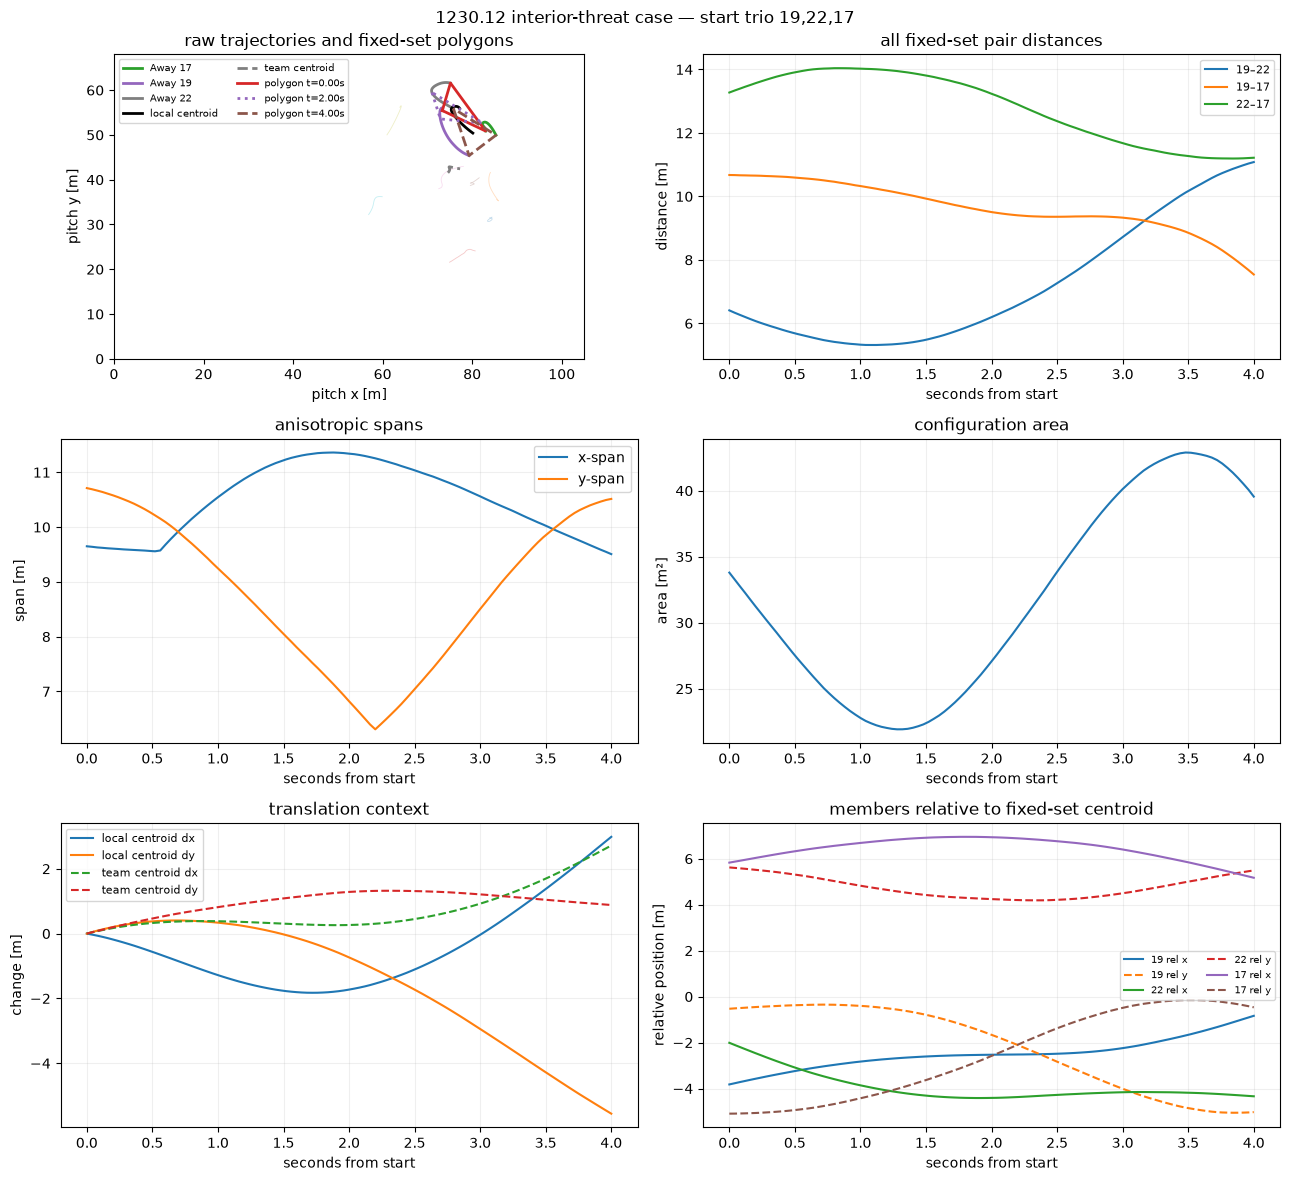

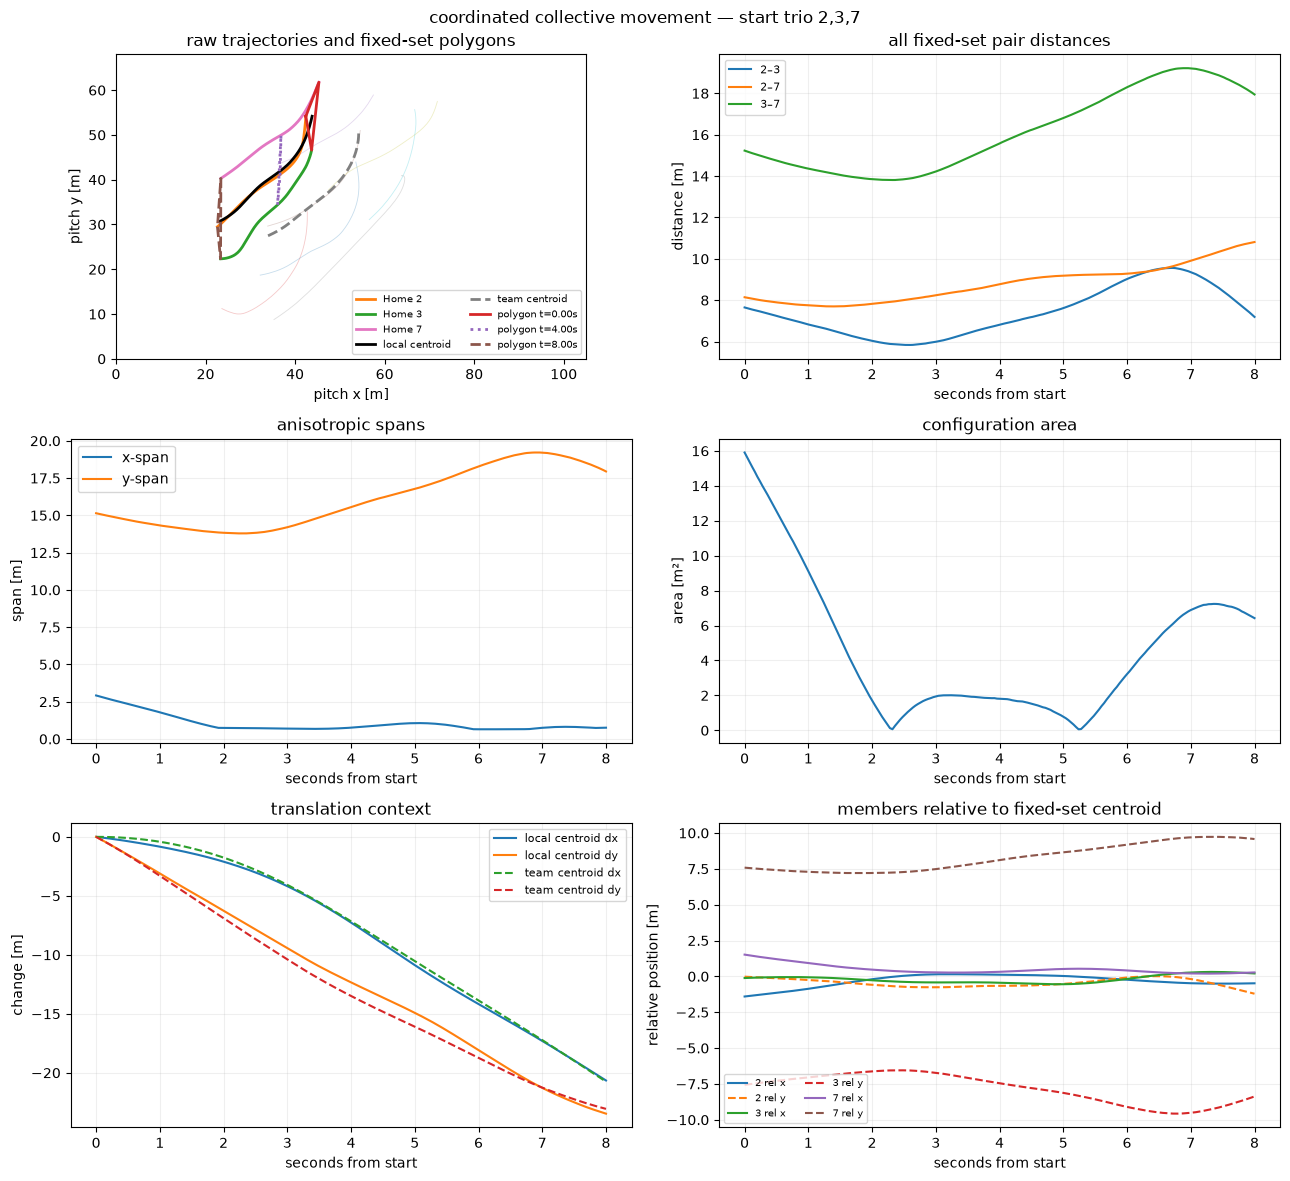

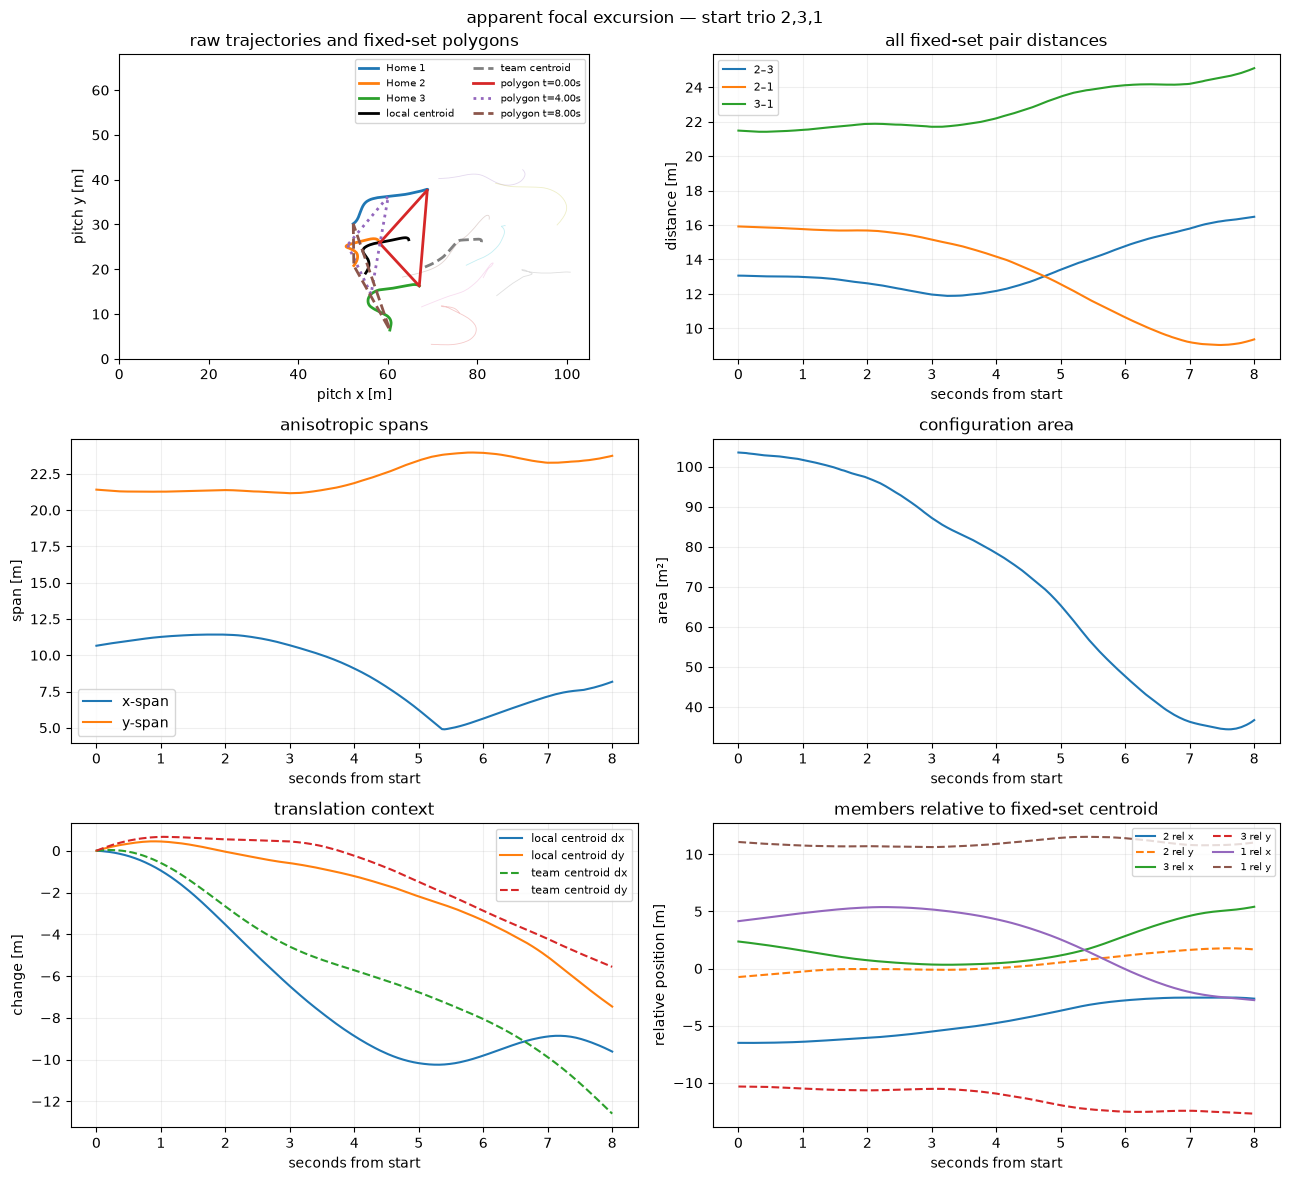

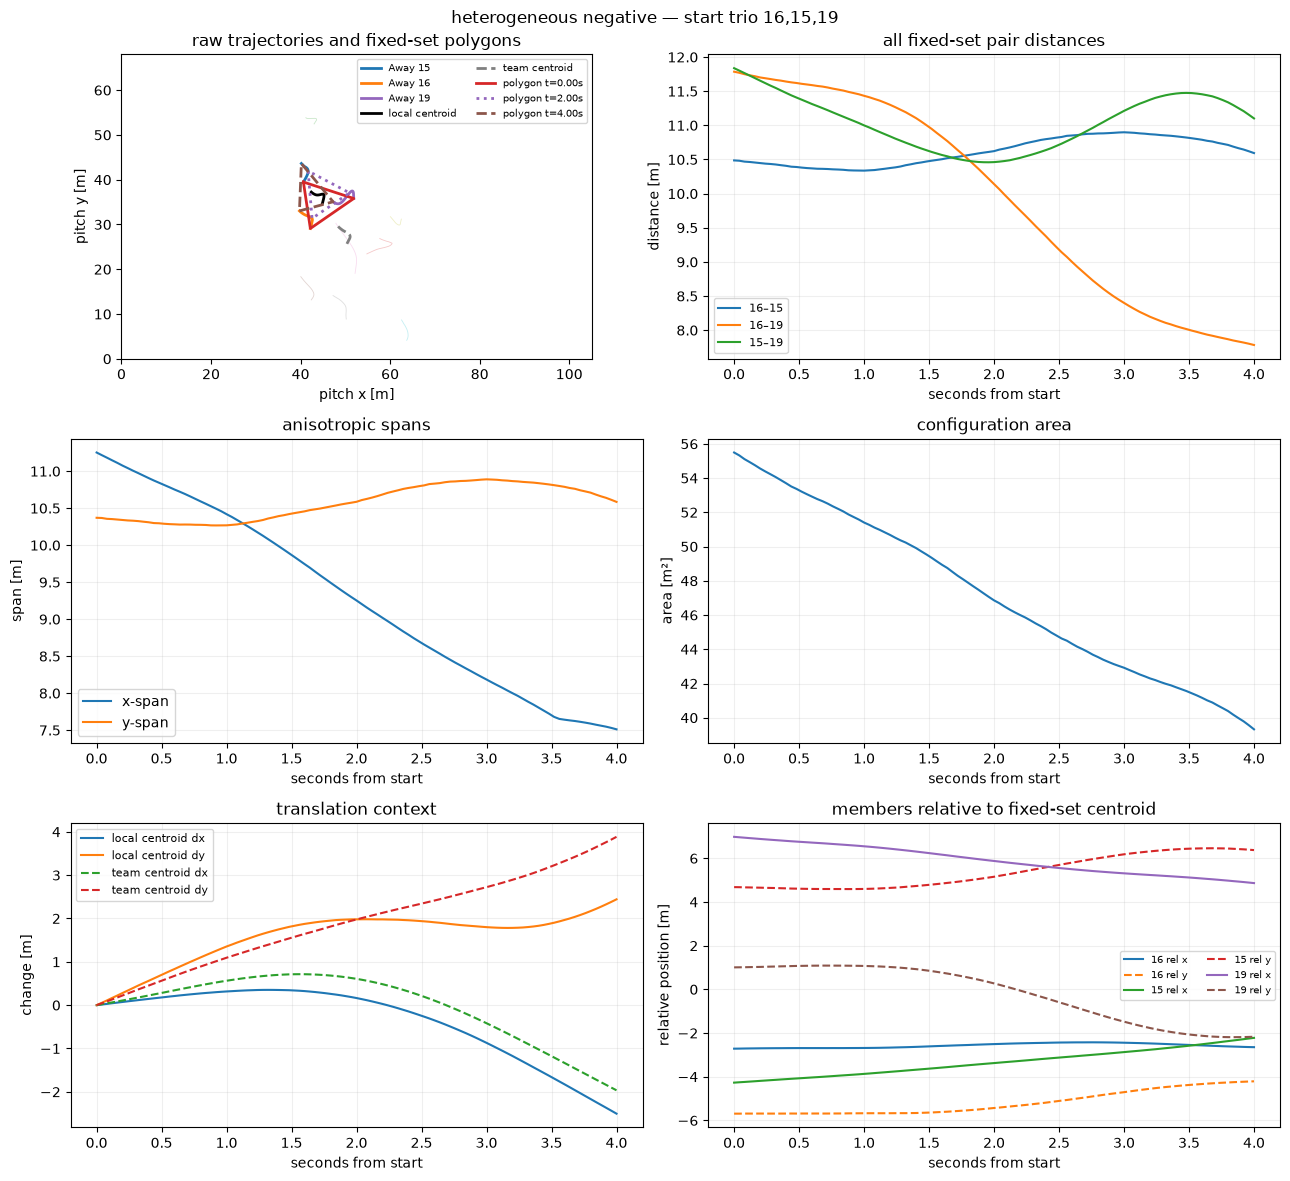

In [5]:
def draw_case(c):
    w,P=c['w'],c['P']; dt=c['def_team']; ids=c['start_trio']; t=w['Time [s]']-c['start']
    outs=outfield(dt); w['team_cx']=w[[f'{dt}_{p}_x' for p in outs]].mean(axis=1)*LENGTH; w['team_cy']=w[[f'{dt}_{p}_y' for p in outs]].mean(axis=1)*WIDTH
    fig,ax=plt.subplots(3,2,figsize=(13,12)); p=ax[0,0]
    for d in outs:
        hi=d in ids; p.plot(w[f'{dt}_{d}_x']*LENGTH,w[f'{dt}_{d}_y']*WIDTH,lw=2 if hi else .6,alpha=1 if hi else .25,label=f'{dt} {d}' if hi else None)
    p.plot(w.tri_cx,w.tri_cy,c='black',lw=2,label='local centroid'); p.plot(w.team_cx,w.team_cy,c='grey',ls='--',lw=2,label='team centroid')
    for j,ls in zip([0,len(w)//2,len(w)-1],['-',':','--']):
        h=hull(P[j]);
        if len(h)>=2: p.plot(np.r_[h[:,0],h[0,0]],np.r_[h[:,1],h[0,1]],ls=ls,lw=2,label=f'polygon t={t.iloc[j]:.2f}s')
    p.set(xlim=(0,LENGTH),ylim=(0,WIDTH),aspect='equal',title='raw trajectories and fixed-set polygons',xlabel='pitch x [m]',ylabel='pitch y [m]'); p.legend(fontsize=7,ncol=2)
    q=ax[0,1]
    for a,b in itertools.combinations(ids,2): q.plot(t,dist_series(w,dt,a,b),label=f'{a}–{b}')
    q.set(title='all fixed-set pair distances',xlabel='seconds from start',ylabel='distance [m]'); q.legend(fontsize=8); q.grid(alpha=.2)
    q=ax[1,0]; q.plot(t,w.tri_xspan,label='x-span'); q.plot(t,w.tri_yspan,label='y-span'); q.set(title='anisotropic spans',xlabel='seconds from start',ylabel='span [m]'); q.legend(); q.grid(alpha=.2)
    q=ax[1,1]; q.plot(t,w.tri_area,label='triangle area'); q.set(title='configuration area',xlabel='seconds from start',ylabel='area [m²]'); q.grid(alpha=.2)
    q=ax[2,0]; q.plot(t,w.tri_cx-w.tri_cx.iloc[0],label='local centroid dx'); q.plot(t,w.tri_cy-w.tri_cy.iloc[0],label='local centroid dy'); q.plot(t,w.team_cx-w.team_cx.iloc[0],ls='--',label='team centroid dx'); q.plot(t,w.team_cy-w.team_cy.iloc[0],ls='--',label='team centroid dy'); q.set(title='translation context',xlabel='seconds from start',ylabel='change [m]'); q.legend(fontsize=8); q.grid(alpha=.2)
    q=ax[2,1]
    for p_id in ids:
        q.plot(t,w[f'tri_{p_id}_relx'],label=f'{p_id} rel x'); q.plot(t,w[f'tri_{p_id}_rely'],ls='--',label=f'{p_id} rel y')
    q.set(title='members relative to fixed-set centroid',xlabel='seconds from start',ylabel='relative position [m]'); q.legend(fontsize=7,ncol=2); q.grid(alpha=.2)
    fig.suptitle(c['name']+' — start trio '+','.join(ids)); fig.tight_layout(); plt.show()
for key in ['1230 interior','1888 translation','590 excursion','4197 negative']:
    draw_case(next(c for c in CASES if c['short']==key))

## Start-trio versus 15 m neighborhood sensitivity

The radius is not optimized. A two-player radius set has pair geometry but no polygon area. Larger sets use convex-hull area, which changes meaning with membership count and must not be compared as though it were a trio triangle.

In [6]:
sens=[]
for c in CASES:
    sens.append(config_summary(c,c['start_trio'],'start trio',c['start']))
    sens.append(config_summary(c,c['start_radius'],'start radius15',c['start']))
sensitivity=pd.DataFrame(sens).set_index(['case','set']); display(sensitivity[['members','n','local centroid net [m]','x-span Δ [m]','y-span Δ [m]','area Δ [m²]','pair Δ [m]','x-order changes','y-order changes']])

members  n  local centroid net [m]  \
case               set                                                         
1888 translation   start trio               2,3,7  3               31.259360   
                   start radius15         2,3,7,6  4               30.868453   
590 excursion      start trio               2,3,1  3               12.172867   
                   start radius15             2,3  2                9.659282   
550.76 tackle      start trio            16,17,15  3               26.643004   
                   start radius15        16,17,15  3               26.643004   
1230 interior      start trio            19,22,17  3                6.305609   
                   start radius15     19,22,17,23  4                3.962199   
1232 accommodation start trio            19,22,23  3                6.739227   
                   start radius15     19,22,23,17  4                7.011987   
3682 overlap       start trio              8,10,5  3               26.354862   
                   start radius15            8,10  2               25.516399   
4197 negative      start trio            16,15,19  3                3.497377   
                   start radius15  16,15,19,18,21  5                4.738352   

                                   x-span Δ [m]  y-span Δ [m]  area Δ [m²]  \
case               set                                                       
1888 translation   start trio          -2.16195       2.80228    -9.480619   
                   start radius15      -0.93450       2.80228     6.068377   
590 excursion      start trio          -2.48115       2.33104   -66.806339   
                   start radius15      -0.82740       4.79672          NaN   
550.76 tackle      start trio          -0.00210      -6.99176   -30.943678   
                   start radius15      -0.00210      -6.99176   -30.943678   
1230 interior      start trio          -0.14280      -0.19720     5.758592   
                   start radius15      -0.57015      -0.80920   -19.413438   
1232 accommodation start trio          10.20285       3.45100    26.560009   
                   start radius15       5.17650       2.30452    -6.973190   
3682 overlap       start trio           2.32365       0.14960    13.140944   
                   start radius15       9.64845       5.57532          NaN   
4197 negative      start trio          -3.74115       0.21488   -16.169703   
                   start radius15       3.75900      -3.64888   -63.982898   

                                                                          pair Δ [m]  \
case               set                                                                 
1888 translation   start trio                        2-3:-0.46, 2-7:+2.67, 3-7:+2.71   
                   start radius15  2-3:-0.46, 2-7:+2.67, 2-6:-1.34, 3-7:+2.71, 3-...   
590 excursion      start trio                        2-3:+3.42, 2-1:-6.56, 3-1:+3.62   
                   start radius15                                          2-3:+3.42   
550.76 tackle      start trio                 16-17:+5.29, 16-15:-11.71, 17-15:-7.44   
                   start radius15             16-17:+5.29, 16-15:-11.71, 17-15:-7.44   
1230 interior      start trio                  19-22:+4.67, 19-17:-3.13, 22-17:-2.05   
                   start radius15  19-22:+4.67, 19-17:-3.13, 19-23:+5.32, 22-17:-...   
1232 accommodation start trio                 19-22:+3.09, 19-23:+12.57, 22-23:+5.31   
                   start radius15  19-22:+3.09, 19-23:+12.57, 19-17:-5.64, 22-23:...   
3682 overlap       start trio                      8-10:+8.85, 8-5:-2.99, 10-5:-3.49   
                   start radius15                                         8-10:+8.85   
4197 negative      start trio                  16-15:+0.11, 16-19:-4.00, 15-19:-0.74   
                   start radius15  16-15:+0.11, 16-19:-4.00, 16-18:+5.12, 16-21:-...   

                                   x-order changes  y-order changes  
case               set           

## Start-time versus anchor-time trio sensitivity

Anchor membership is fixed from the pre-existing anchor frame and traced over the same full window. It is not allowed to replace the primary start trio. Differences indicate reference-time sensitivity.

In [7]:
anchors=[]
for c in CASES:
    if 'anchor' not in c: continue
    anchors.append(config_summary(c,c['start_trio'],'start trio',c['start']))
    anchors.append(config_summary(c,c['anchor_trio'],'anchor trio',c['anchor']))
anchor_table=pd.DataFrame(anchors).set_index(['case','set']); display(anchor_table[['reference s','members','local centroid net [m]','x-span Δ [m]','y-span Δ [m]','area Δ [m²]','pair Δ [m]','x-order changes','y-order changes']])

reference s   members  local centroid net [m]  \
case               set                                                          
550.76 tackle      start trio        550.76  16,17,15               26.643004   
                   anchor trio       550.76  16,17,15               26.643004   
1230 interior      start trio       1228.12  19,22,17                6.305609   
                   anchor trio      1230.12  19,22,23                4.506429   
1232 accommodation start trio       1229.28  19,22,23                6.739227   
                   anchor trio      1232.28  19,21,20                5.686030   
3682 overlap       start trio       3679.88    8,10,5               26.354862   
                   anchor trio      3682.88    8,5,10               26.354862   
4197 negative      start trio       4195.04  16,15,19                3.497377   
                   anchor trio      4197.04  16,19,15                3.497377   

                                x-span Δ [m]  y-span Δ [m]  area Δ [m²]  \
case               set                                                    
550.76 tackle      start trio       -0.00210      -6.99176   -30.943678   
                   anchor trio      -0.00210      -6.99176   -30.943678   
1230 interior      start trio       -0.14280      -0.19720     5.758592   
                   anchor trio       1.26210      -0.80920    29.229439   
1232 accommodation start trio       10.20285       3.45100    26.560009   
                   anchor trio      -5.45580     -13.00364   -57.211376   
3682 overlap       start trio        2.32365       0.14960    13.140944   
                   anchor trio       2.32365       0.14960    13.140944   
4197 negative      start trio       -3.74115       0.21488   -16.169703   
                   anchor trio      -3.74115       0.21488   -16.169703   

                                                             pair Δ [m]  \
case               set                                                    
550.76 tackle      start trio    16-17:+5.29, 16-15:-11.71, 17-15:-7.44   
                   anchor trio   16-17:+5.29, 16-15:-11.71, 17-15:-7.44   
1230 interior      start trio     19-22:+4.67, 19-17:-3.13, 22-17:-2.05   
                   anchor trio    19-22:+4.67, 19-23:+5.32, 22-23:-6.36   
1232 accommodation start trio    19-22:+3.09, 19-23:+12.57, 22-23:+5.31   
                   anchor trio  19-21:-12.74, 19-20:-15.35, 21-20:-4.83   
3682 overlap       start trio         8-10:+8.85, 8-5:-2.99, 10-5:-3.49   
                   anchor trio        8-5:-2.99, 8-10:+8.85, 5-10:-3.49   
4197 negative      start trio     16-15:+0.11, 16-19:-4.00, 15-19:-0.74   
                   anchor trio    16-19:-4.00, 16-15:+0.11, 19-15:-0.74   

                                x-order changes  y-order changes  
case               set                                            
550.76 tackle      start trio                 2                1  
                   anchor trio                2                1  
1230 interior      start trio                 1                1  
                   anchor trio                1                2  
1232 accommodation start trio                 0                2  
                   anchor trio                3                2  
3682 overlap       start trio                 0                1  
                   anchor trio                0                1  
4197 negative      start trio                 1                0  
                   anchor trio                1                0

## Descriptor audit and falsification questions

The executed outputs are interpreted under these constraints:

- **Pair distances** preserve which relationships contract or expand; mixed signs cannot be relabeled as uniform compression.
- **x/y spans** summarize directional extent but discard which defender pair defines each extreme.
- **Area** detects some deformation but can hide x-compression with y-expansion, rotation, or different shapes with equal area.
- **Ordering** makes crossing/reordering visible but is sensitive to small component crossings and is not tactical rotation inference.
- **Local-centroid-relative positions** preserve member-specific deformation while removing local translation; they are not a combined deformation magnitude.
- **Local-centroid motion** describes translation of the selected set and cannot establish deformation.

Fixed membership can become stale, particularly when ordering changes repeatedly or the start-nearest identities cease to be locally nearest. This is a limitation to report, not permission to introduce dynamic membership or handoff inference.

## Conservative conclusion

The final judgment is based on the executed tables, not on recovering the original visual story. It must distinguish whether the primary start trio, the 15 m set, and anchor trio agree; whether area conceals anisotropy; and whether the negative case stays heterogeneous.

### Findings by fixed case

- **1230.12 primary start trio (Away19/22/17):** local-centroid translation is 6.306 m. x-span changes −0.143 m, y-span −0.197 m, and triangle area **increases** 5.759 m². Pair changes are mixed (+4.67, −3.13, −2.05 m) and both x/y ordering change. This is deformation, but not a clean whole-configuration contraction. The 15 m set (19/22/17/23) contracts modestly in x/y and hull area while retaining mixed pairs. The anchor trio (19/22/23) expands in x and area while contracting in y. The original Away19/20/21 visual story is therefore not recovered prospectively in this window.
- **1888–1896 coordinated translation:** the start trio centroid moves 31.259 m while x/y spans change −2.162/+2.802 m and area −9.481 m². Internal geometry is non-rigid, but its deformation is comparatively smaller than translation.
- **590–598 excursion:** the start trio centroid moves 12.173 m; area falls 66.806 m² while x contracts 2.481 m and y expands 2.331 m. Pair changes are mixed (+3.42, −6.56, +3.62 m). The focal defender moves 4.57 m relative to the local centroid, but teammate Home1 moves 6.91 m, so this configuration view does not uniquely isolate the focal player. It preserves anisotropic deformation and reordering while the previously established leave-one-out team-centroid view remains more informative for focal excursion.
- **3682.88 overlap:** local centroid translation is 26.355 m while x/y spans and area expand (+2.324 m, +0.150 m, +13.141 m²); two pairs contract but the focal–teammate pair expands 8.85 m. Configuration deformation coexists with translation, but prospective geometry does not support a clean compression label.
- **4197.04 negative:** the start trio has x contraction, nearly stable y span, area loss, and two contracting/one nearly stable pair. The larger 15 m set instead expands in x, contracts in y, and contains mixed pair directions. The case therefore does not remain “no deformation”; it remains heterogeneous and demonstrates that generic deformation or area loss alone would overcall a compression-like story.

### Sensitivity and descriptor judgments

- **Fixed local set:** useful but context-sensitive. It makes translation/deformation separable and falsifiable, but start, radius, and anchor membership can materially change the account.
- **Pairwise distances:** necessary for identity and mixed direction; insufficient alone as a configuration summary.
- **x/y spans:** useful for anisotropy; they hide which members define the extremes.
- **Area:** useful only beside spans and pairs; it can contradict them or hide anisotropic change.
- **Relative ordering:** useful evidence of reordering, but small crossings make it sensitive and non-tactical.
- **Local-centroid-relative positions:** the most informative member-preserving view of deformation after local translation is removed; still membership-dependent.

## Outcome: B — partially supported

**Local configuration deformation is a more defensible descriptive primitive than local compression**, because prospective fixed sets routinely show contraction, expansion, anisotropic change, reordering, and mixed deformation rather than one uniform contraction pattern. Compression should be weakened to one possible subtype, not retained as the general motif name.

This is only a partial improvement. The 1230 story changes across start-trio, radius, and anchor sets; the original hand-selected convergence is not recovered by the primary rule; and the 4197 negative also exhibits substantial deformation. Configuration descriptors therefore preserve how a chosen set changes, but do not by themselves establish meaningful defensive reconfiguration, attacker induction, or a motif. No descriptor is combined into a score.